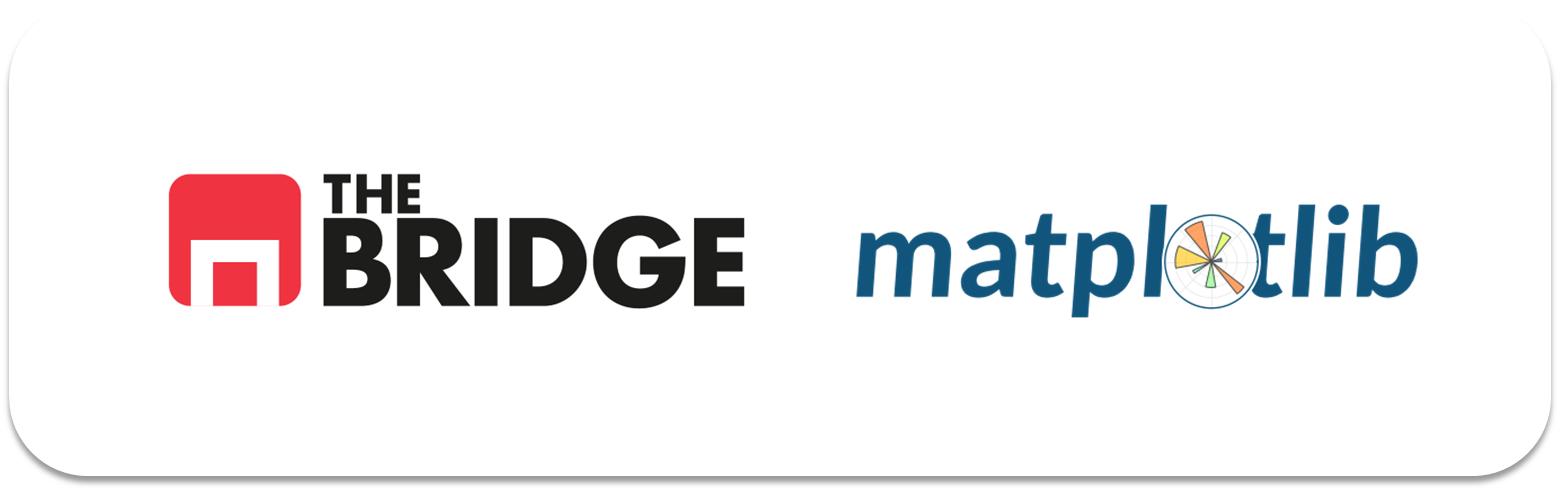

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [17]:
# Cargar dataset
df = pd.read_csv("./data/california_cities.csv")

# Ver primeras filas
df.head()

# Información general
df.info()

# Descripción estadística
df.describe()

# Eliminar nulos
df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

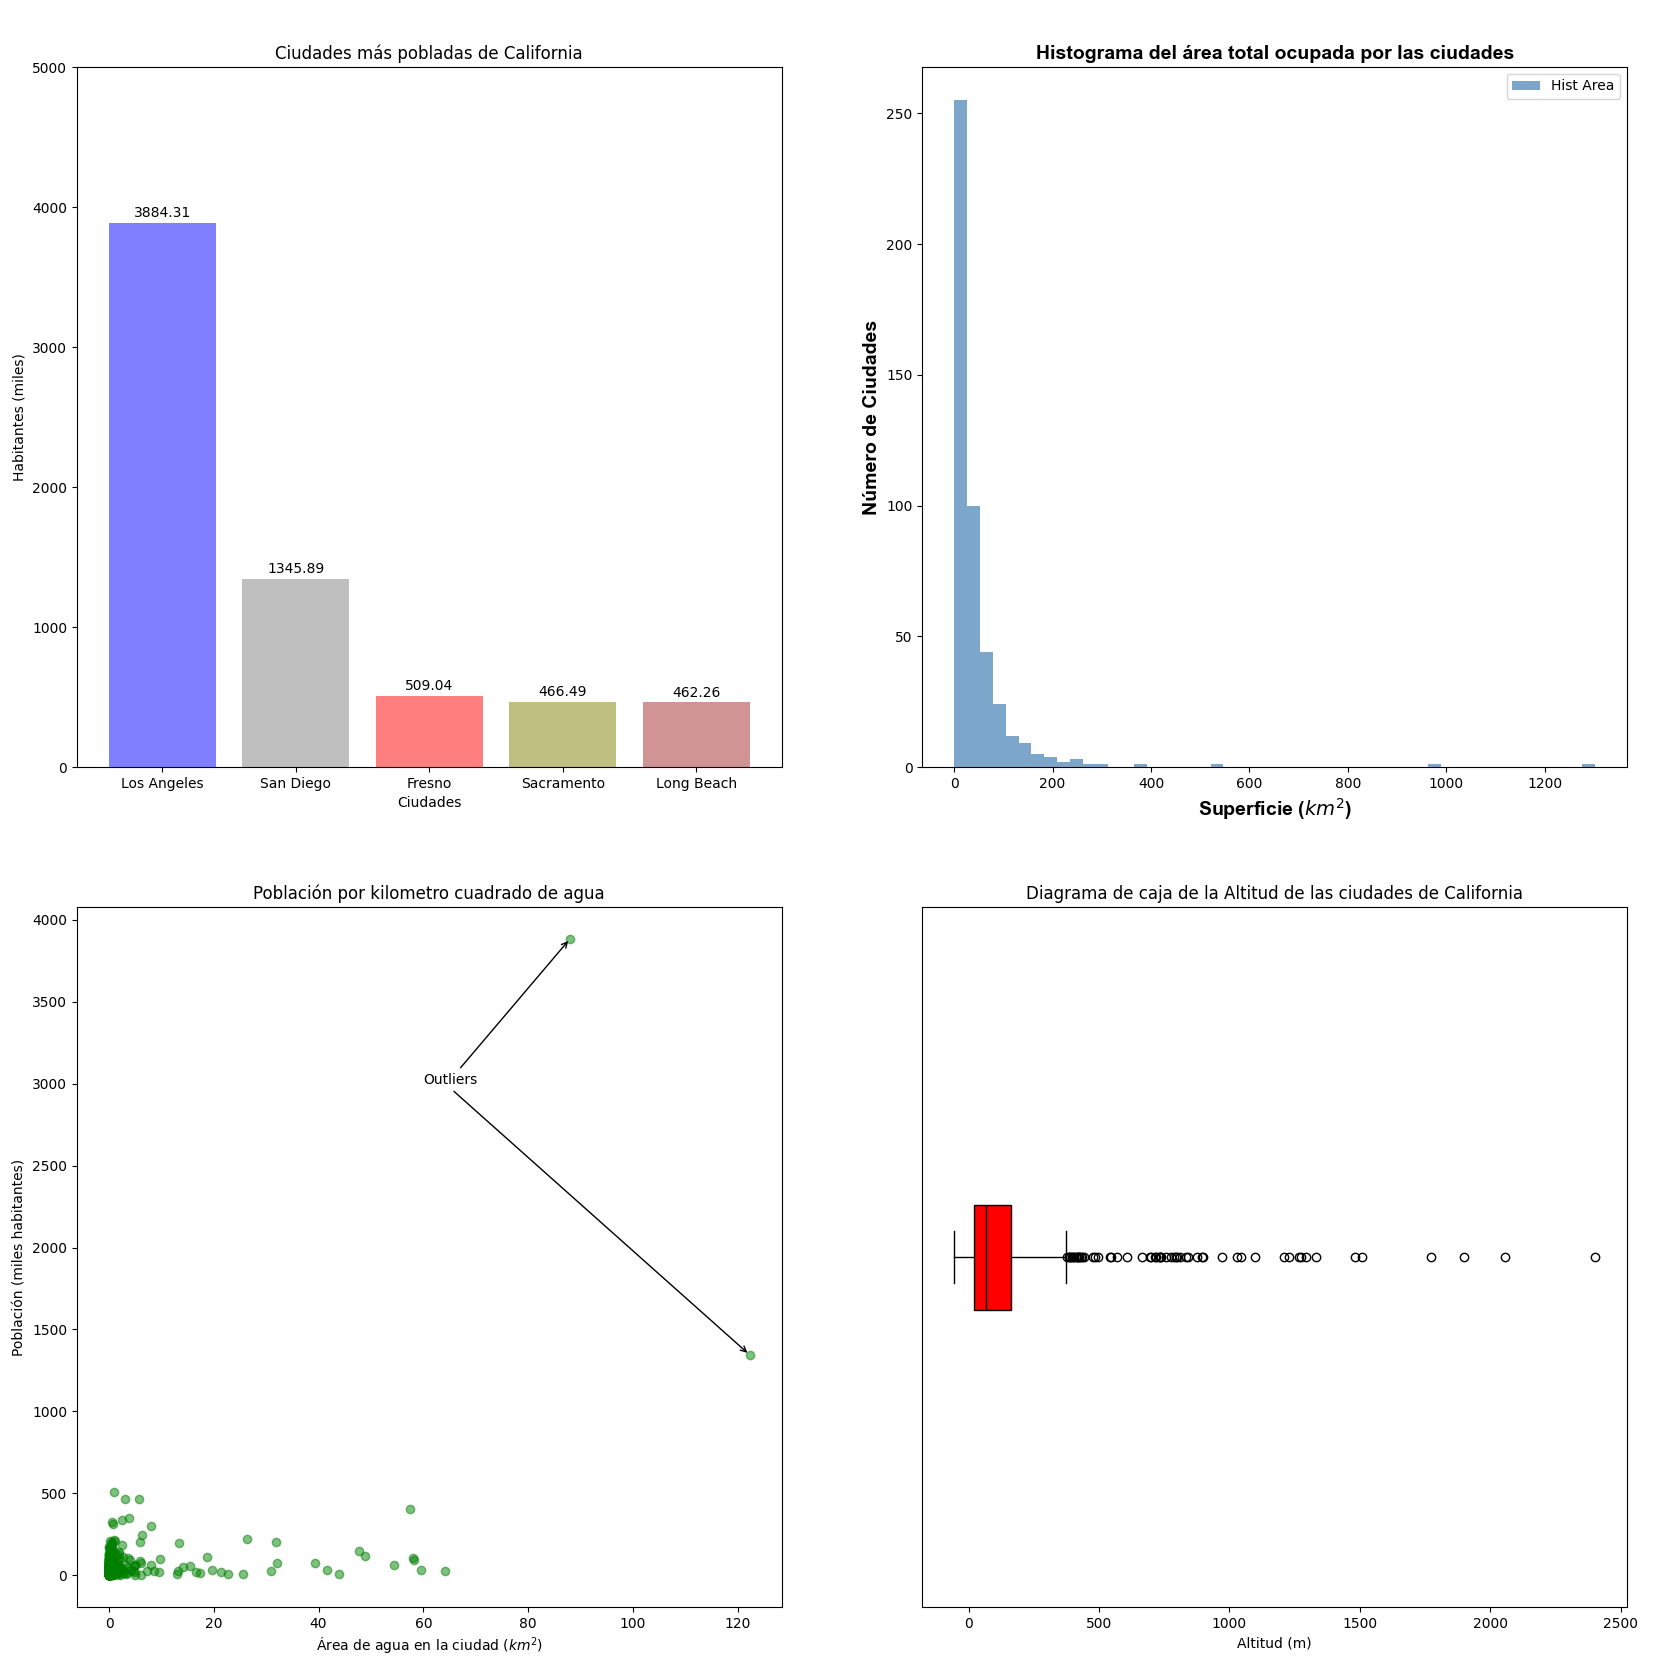

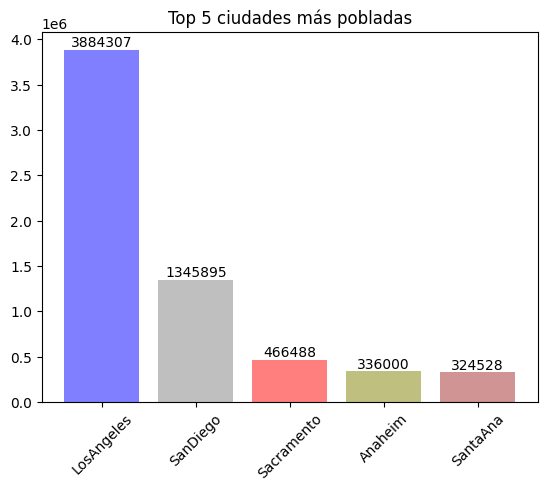

In [18]:
# Top 5 ciudades más pobladas
top_cities = df.sort_values(by="population_total", ascending=False).head(5)

colors = ["blue", "grey", "red", "olive", "brown"]

plt.figure()
bars = plt.bar(top_cities["city"], top_cities["population_total"], color=colors, alpha=0.5)

# Añadir etiquetas
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{int(height)}",
             ha='center', va='bottom')

plt.title("Top 5 ciudades más pobladas")
plt.xticks(rotation=45)
plt.show()

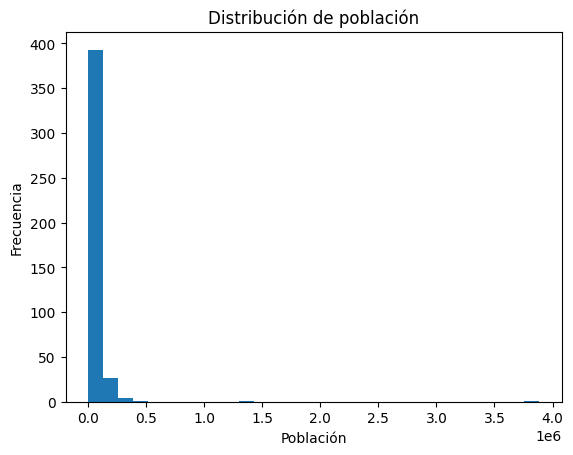

In [19]:
plt.figure()
plt.hist(df["population_total"], bins=30)
plt.title("Distribución de población")
plt.xlabel("Población")
plt.ylabel("Frecuencia")
plt.show()

In [20]:
df.columns

Index(['Unnamed: 0', 'city', 'latd', 'longd', 'elevation_m', 'elevation_ft',
       'population_total', 'area_total_sq_mi', 'area_land_sq_mi',
       'area_water_sq_mi', 'area_total_km2', 'area_land_km2', 'area_water_km2',
       'area_water_percent'],
      dtype='object')

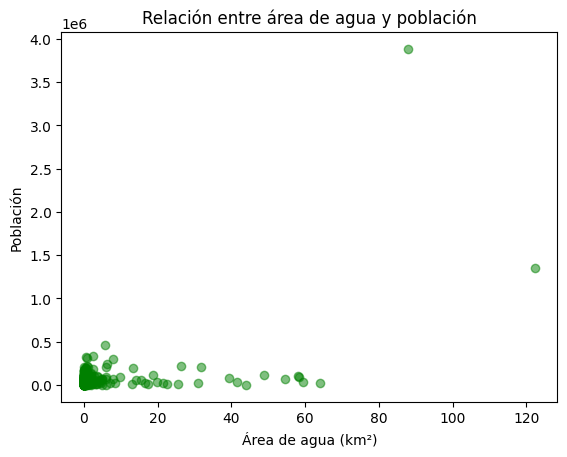

In [21]:
plt.figure()

plt.scatter(df["area_water_km2"], df["population_total"],
            alpha=0.5, color="green")

plt.title("Relación entre área de agua y población")
plt.xlabel("Área de agua (km²)")
plt.ylabel("Población")

plt.show()

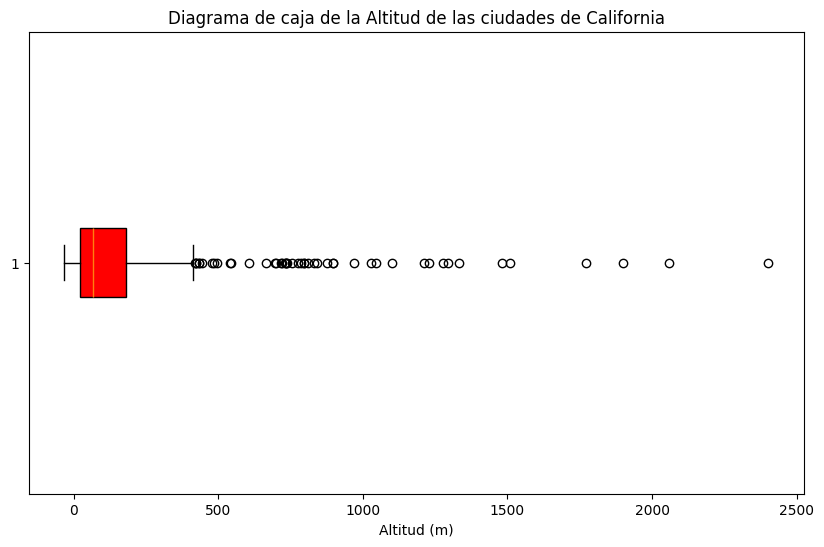

In [22]:
plt.figure(figsize=(10,6))

plt.boxplot(df["elevation_m"].dropna(),
            vert=False,                 # ← horizontal
            patch_artist=True,          # ← permite color
            boxprops=dict(facecolor="red"))

plt.title("Diagrama de caja de la Altitud de las ciudades de California")
plt.xlabel("Altitud (m)")

plt.show()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

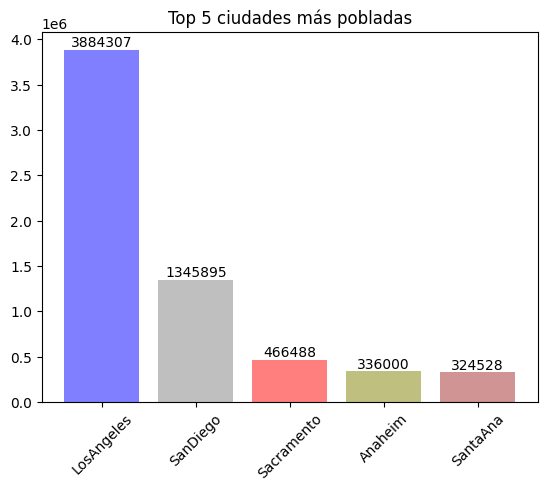

In [23]:
# Top 5 ciudades más pobladas 
top_cities = df.sort_values(by="population_total", ascending=False).head(5)

colors = ["blue", "grey", "red", "olive", "brown"]

plt.figure()
bars = plt.bar(top_cities["city"], top_cities["population_total"], color=colors, alpha=0.5)

# Añadir etiquetas
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{int(height)}",
             ha='center', va='bottom')

plt.title("Top 5 ciudades más pobladas")
plt.xticks(rotation=45)

# 🔴 Guardar figura
plt.savefig("top_5_ciudades.png", dpi=300, bbox_inches='tight')

plt.show()

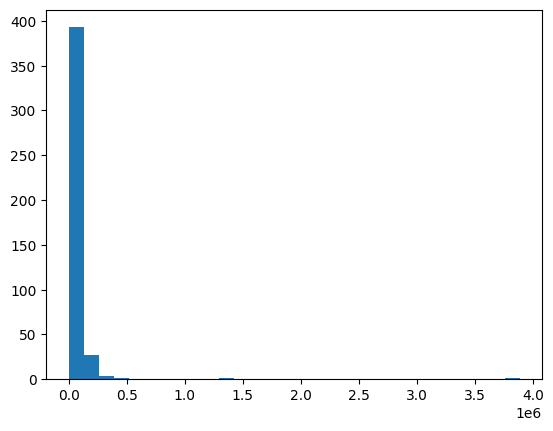

In [24]:
fig = plt.figure()
plt.hist(df["population_total"], bins=30)

fig.savefig("histograma.png", dpi=300, bbox_inches='tight')

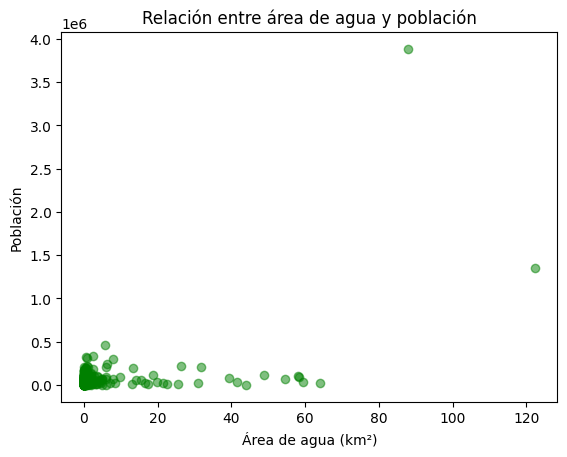

In [25]:
plt.figure()

plt.scatter(df["area_water_km2"], df["population_total"],
            alpha=0.5, color="green")

plt.title("Relación entre área de agua y población")
plt.xlabel("Área de agua (km²)")
plt.ylabel("Población")

# 🔴 Guardar figura
plt.savefig("scatter_agua_poblacion.png", dpi=300, bbox_inches='tight')

plt.show()

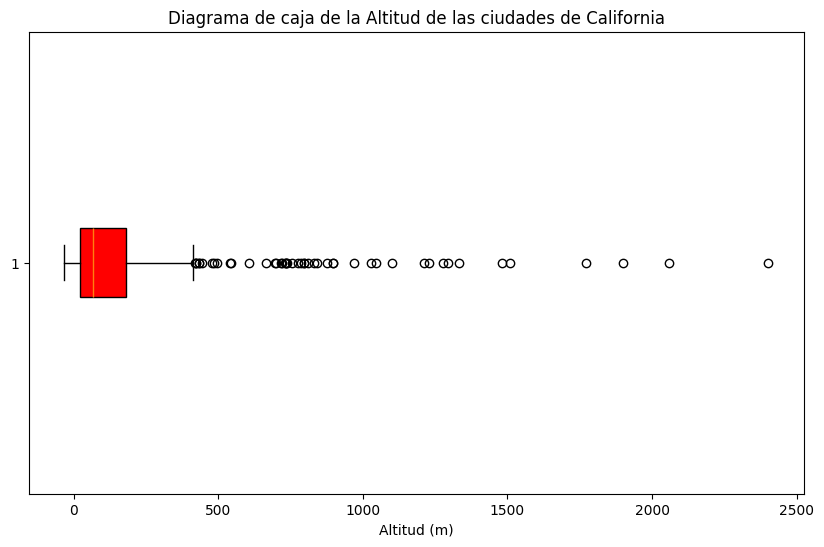

In [26]:
plt.figure(figsize=(10,6))

plt.boxplot(df["elevation_m"].dropna(),
            vert=False,
            patch_artist=True,
            boxprops=dict(facecolor="red"))

plt.title("Diagrama de caja de la Altitud de las ciudades de California")
plt.xlabel("Altitud (m)")

# 🔴 GUARDAR FIGURA
plt.savefig("boxplot_altitud_california.png")

plt.show()